In [524]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
import matplotlib.pyplot as plt

In [525]:
TEST_SIZE = 0.2
RANDOM_STATE = 43

In [526]:
df = pd.read_csv('data/games_list.csv')
# df = df.sort_values(by='avg_concurrent_players_after_90',ascending=True).iloc[10:]


In [527]:

df['log_estimated_launch_copies'] = np.log1p(df['estimated_launch_copies_sold'])
df['log_estimated_launch_reviews'] = np.log1p(df['estimated_launch_reviews'])
df['log_estimated_launch_followers'] = np.log1p(df['estimated_launch_followers'])
df['log_avg_playtime'] = np.log1p(df['avg_playtime'])
df['log_review_score'] = np.log1p(df['review_score'])
df['log_avg_concurrent_players_after_90'] = np.log1p(df['avg_concurrent_players_after_90'])


# Log calculations 
df['log_review_to_follower_ratio'] = df['log_estimated_launch_reviews'] - df['log_estimated_launch_followers']
df['log_copies_to_follower_ratio'] = df['log_estimated_launch_copies'] - df['log_estimated_launch_followers']
# ratios for logs are subtraction due to the rules of logs log(a/b) = log(a) - log(b)
df['log_engagement_quality'] = df['log_avg_playtime'] + df['log_review_score']
# log (a*b) = log(a) + log(b)
df['log_virality_factor'] = df['log_review_to_follower_ratio'] + df['log_review_score']

# features we want to train on
features = [
    'log_estimated_launch_copies',
    'log_review_to_follower_ratio',
    'log_copies_to_follower_ratio',
    'log_engagement_quality',
    'log_virality_factor',
    'log_review_score',
    'avg_sentiment'
]





In [528]:
X = df[features]
y = df['log_avg_concurrent_players_after_90']
X.head(1)

,log_estimated_launch_copies,log_review_to_follower_ratio,log_copies_to_follower_ratio,log_engagement_quality,log_virality_factor,log_review_score,avg_sentiment
0,14.077096,0.633798,4.864628,7.158785,5.228918,4.59512,0.453232


In [529]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE)

In [530]:
# standard random forest without any settings changed
random_forest_base = RandomForestRegressor(n_estimators=100,max_features=1/3,oob_score=True, random_state=RANDOM_STATE)
random_forest_base.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.3333333333333333
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [531]:
y_pred_log = random_forest_base.predict(X_test)

In [532]:
mean_absolute_error(y_test, y_pred_log)

1.0574101355296661

In [533]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
mean_absolute_error(y_test_orig,y_pred_orig)

2315.7486907226607

In [534]:
mean_squared_error(y_test_orig,y_pred_orig)

8818378.476407902

In [535]:
r2_score(y_test_orig,y_pred_orig)

0.9433104655248455

In [536]:
params= {
    'n_estimators': [200, 500],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 2, 5]
}

In [537]:
random_forest_cv = GridSearchCV(estimator=random_forest_base,param_grid=params,cv=3,scoring='r2',n_jobs=-1)

In [538]:
sample_weights = 1 / np.sqrt(np.expm1(y))  
X_train, X_test, y_train, y_test= train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)
random_forest_cv.fit(X_train,y_train)

,estimator,RandomForestR...ndom_state=43)
,param_grid,"{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [200, 500]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [539]:
y_pred_log = random_forest_cv.predict(X_test)

In [540]:
mean_absolute_error(y_test, y_pred_log)

1.065667714165241

In [541]:
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
mean_absolute_error(y_test_orig,y_pred_orig)

2036.2943851580944

In [542]:
r2_score(y_test_orig,y_pred_orig)

0.9535632669741702

In [543]:
root_mean_squared_error(y_pred=y_pred_orig,y_true=y_test_orig)

2687.656429860713

In [544]:
X.head(1)

,log_estimated_launch_copies,log_review_to_follower_ratio,log_copies_to_follower_ratio,log_engagement_quality,log_virality_factor,log_review_score,avg_sentiment
0,14.077096,0.633798,4.864628,7.158785,5.228918,4.59512,0.453232


# New Data Test
This code below is used for testing new games that aren't in our data

In [545]:
from add_new_games import fetch_gamalytic_data, fetch_game,get_sentiment_data

user_input = str(input('Enter name of game'))
appid = fetch_game(user_input)
new_game = fetch_gamalytic_data(appid=appid)
new_game = get_sentiment_data(new_game)


# Convert to DataFrame
df = pd.DataFrame([new_game])

# Log-transform base features
df['log_estimated_launch_reviews'] = np.log1p(df['estimated_launch_reviews'])
df['log_estimated_launch_followers'] = np.log1p(df['estimated_launch_followers'])
df['log_estimated_launch_copies'] = np.log1p(df['estimated_launch_copies_sold'])
df['log_avg_playtime'] = np.log1p(df['avg_playtime'])
df['log_review_score'] = np.log1p(df['review_score'])

# Engineer features (same as training)
df['log_review_to_follower_ratio'] = df['log_estimated_launch_reviews'] - df['log_estimated_launch_followers']
df['log_copies_to_follower_ratio'] = df['log_estimated_launch_copies'] - df['log_estimated_launch_followers']
df['log_engagement_quality'] = df['log_avg_playtime'] + df['log_review_score']
df['log_virality_factor'] = df['log_review_to_follower_ratio'] + df['log_review_score']

# Select features (same order as training)
features = [
    'log_estimated_launch_copies',
    'log_review_to_follower_ratio',
    'log_copies_to_follower_ratio',
    'log_engagement_quality',
    'log_virality_factor',
    'log_review_score',
    'avg_sentiment'
]

X_new = df[features]

# Predict
y_pred_log = random_forest_cv.predict(X_new)
y_pred_original = np.expm1(y_pred_log)

print(f"\n{'='*60}")
print(f"Prediction for: {new_game['name']}")
print(f"{'='*60}")
print(f"Expected avg concurrent players (90 days): {y_pred_original[0]:,.0f}")
print(f"{'='*60}")


1. Apex Legends™
2. Space Engineers - Apex Survival Pack
3. Arma 3 Apex
4. Forza Horizon 5 Apex Allstars Car Pack
5. Apex Point
Calculating average sentiment...

Prediction for: Apex Legends
Expected avg concurrent players (90 days): 56,556


In [546]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_log_lr = model.predict(X_test)

In [547]:
y_pred_lr = np.exp(y_pred_log_lr)
y_true_lr = np.exp(y_test)


mae = mean_absolute_error(y_true_lr, y_pred_lr)
rmse = root_mean_squared_error(y_true_lr, y_pred_lr)
print(f"MAE: {mae}, RMSE: {rmse}")


MAE: 2763.348324500407, RMSE: 4112.457663090494


                        feature  importance
3        log_engagement_quality    0.363379
0   log_estimated_launch_copies    0.310991
2  log_copies_to_follower_ratio    0.080893
5              log_review_score    0.066610
6                 avg_sentiment    0.066594
1  log_review_to_follower_ratio    0.055943
4           log_virality_factor    0.055590


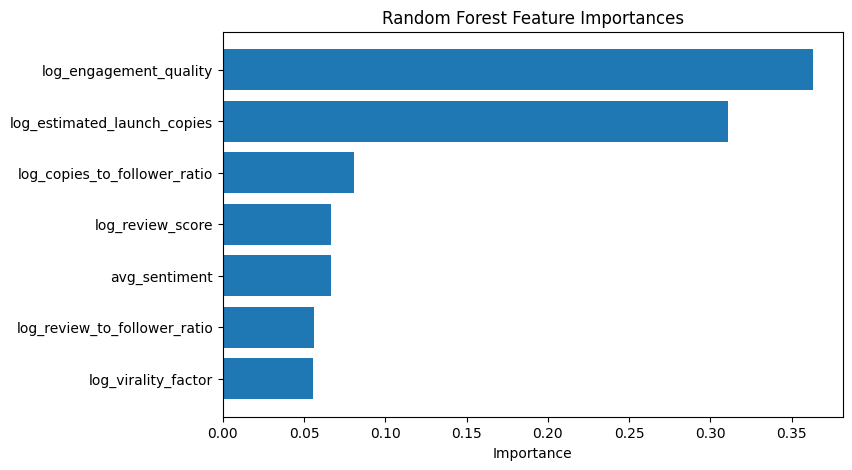

In [548]:
importances = random_forest_cv.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values(by='importance', ascending=False)


print(feature_importance_df)

# Optional: plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()